# The Entrepreneur: Boom and Bust under an Unrealized-Gains Tax

**Scenario.** A founder starts a company. Her shares are worth essentially nothing on day 1 (her cost basis). The company raises money, the implied valuation climbs, and by year 5 her stake is paper-worth tens of millions of dollars. Then the business fails, and by year 8 the stock is worthless.

Under a 20% annual mark-to-market tax on unrealized capital gains, what does her tax bill look like, year by year?

We model two regimes:

1. **Non-refundable** — paper gains are taxed every year; paper losses get a credit only against future paper gains. If the company goes to zero, leftover loss carryforwards are worthless.
2. **Symmetric (refundable)** — paper losses generate an immediate refund at the same 20% rate. The IRS pays you in down years.

Both regimes have problems. The first creates **liquidity crises and net negative outcomes** for failed founders. The second turns the Treasury into a co-investor that writes checks during recessions — politically and fiscally implausible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Inputs

In [2]:
# --- Founder's stake -------------------------------------------------
founder_ownership = 0.40        # fraction of company owned after dilution
cost_basis        = 10_000      # what she paid for her founder shares

# --- Company valuation path -----------------------------------------
# Years 0..10. Valuation rises (priced rounds), peaks, then collapses.
years = np.arange(0, 11)
company_valuation = np.array([
    1_000_000,      #  0: founding, nominal
    5_000_000,      #  1: seed round
    25_000_000,     #  2: Series A
    80_000_000,     #  3: Series B
    200_000_000,    #  4: Series C
    400_000_000,    #  5: peak — Series D at unicorn-ish valuation
    250_000_000,    #  6: growth disappoints, down round
    90_000_000,     #  7: revenue stalls, layoffs
    20_000_000,     #  8: distressed bridge round
    2_000_000,      #  9: assignment for benefit of creditors
    0,              # 10: wound down
])

# --- Tax regime ------------------------------------------------------
tax_rate = 0.20

# Founder's salary — what she can actually pay tax from without selling stock.
# Most venture-backed founders draw modest salaries while the company is private.
annual_salary = 250_000

## Year-by-year simulation

In [3]:
stake_value = company_valuation * founder_ownership

# Annual change in paper value of the founder's stake.
# Year 0 gain is measured against cost basis; thereafter against prior year mark.
prior_mark = np.concatenate([[cost_basis], stake_value[:-1]])
annual_gain = stake_value - prior_mark   # signed: negative in down years

# --- Regime 1: non-refundable, loss carryforward only ---------------
tax_nonref = np.zeros_like(annual_gain, dtype=float)
carryforward = 0.0
for i, g in enumerate(annual_gain):
    if g >= 0:
        taxable = max(0.0, g - carryforward)
        carryforward = max(0.0, carryforward - g)
        tax_nonref[i] = tax_rate * taxable
    else:
        # paper loss adds to carryforward; no current-year refund
        carryforward += -g
        tax_nonref[i] = 0.0

# --- Regime 2: symmetric, immediate refund on losses ---------------
tax_sym = tax_rate * annual_gain        # negative tax = refund

df = pd.DataFrame({
    'year':              years,
    'company_valuation': company_valuation,
    'stake_value':       stake_value,
    'annual_gain':       annual_gain,
    'tax_nonref':        tax_nonref,
    'tax_symmetric':     tax_sym,
    'salary':            annual_salary,
})
df['cum_tax_nonref']    = df['tax_nonref'].cumsum()
df['cum_tax_symmetric'] = df['tax_symmetric'].cumsum()
df['tax_vs_salary']     = df['tax_nonref'] / df['salary']
df.round(0)

,year,company_valuation,stake_value,annual_gain,tax_nonref,tax_symmetric,salary,cum_tax_nonref,cum_tax_symmetric,tax_vs_salary
0,0,1000000,400000.0,390000.0,78000.0,78000.0,250000,78000.0,78000.0,0.0
1,1,5000000,2000000.0,1600000.0,320000.0,320000.0,250000,398000.0,398000.0,1.0
2,2,25000000,10000000.0,8000000.0,1600000.0,1600000.0,250000,1998000.0,1998000.0,6.0
3,3,80000000,32000000.0,22000000.0,4400000.0,4400000.0,250000,6398000.0,6398000.0,18.0
4,4,200000000,80000000.0,48000000.0,9600000.0,9600000.0,250000,15998000.0,15998000.0,38.0
5,5,400000000,160000000.0,80000000.0,16000000.0,16000000.0,250000,31998000.0,31998000.0,64.0
6,6,250000000,100000000.0,-60000000.0,0.0,-12000000.0,250000,31998000.0,19998000.0,0.0
7,7,90000000,36000000.0,-64000000.0,0.0,-12800000.0,250000,31998000.0,7198000.0,0.0
8,8,20000000,8000000.0,-28000000.0,0.0,-5600000.0,250000,31998000.0,1598000.0,0.0
9,9,2000000,800000.0,-7200000.0,0.0,-1440000.0,250000,31998000.0,158000.0,0.0


## The headline numbers

In [4]:
total_paid_nonref = df['tax_nonref'].sum()
total_paid_sym    = df['tax_symmetric'].sum()
final_stake       = stake_value[-1]
peak_stake        = stake_value.max()

print(f"Peak paper value of stake:      ${peak_stake:>15,.0f}")
print(f"Final value of stake:           ${final_stake:>15,.0f}")
print()
print(f"Total tax paid, non-refundable: ${total_paid_nonref:>15,.0f}")
print(f"Total tax paid, symmetric:      ${total_paid_sym:>15,.0f}")
print()
print(f"Net cash outcome, non-refundable: ${final_stake - total_paid_nonref:>15,.0f}")
print(f"Net cash outcome, symmetric:      ${final_stake - total_paid_sym:>15,.0f}")
print()
max_year_tax = df.loc[df['tax_nonref'].idxmax()]
print(f"Worst year (non-refundable): year {int(max_year_tax['year'])}, tax owed ${max_year_tax['tax_nonref']:,.0f}")
print(f"  ...which is {max_year_tax['tax_nonref']/annual_salary:,.1f}x her annual salary.")

Peak paper value of stake:      $    160,000,000
Final value of stake:           $              0

Total tax paid, non-refundable: $     31,998,000
Total tax paid, symmetric:      $         -2,000

Net cash outcome, non-refundable: $    -31,998,000
Net cash outcome, symmetric:      $          2,000

Worst year (non-refundable): year 5, tax owed $16,000,000
  ...which is 64.0x her annual salary.


## Charts

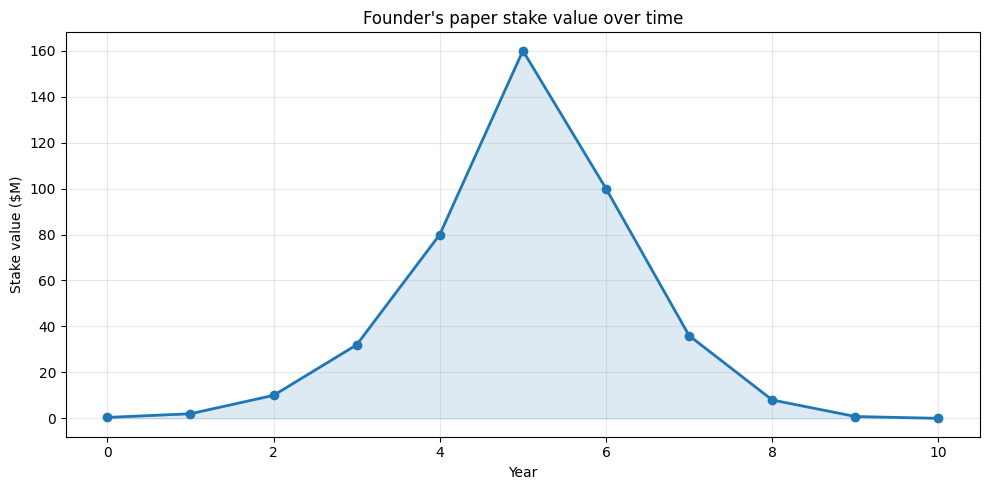

In [5]:
fig, ax = plt.subplots()
ax.plot(df['year'], df['stake_value']/1e6, marker='o', linewidth=2, color='#1f77b4')
ax.fill_between(df['year'], 0, df['stake_value']/1e6, alpha=0.15, color='#1f77b4')
ax.set_title("Founder's paper stake value over time")
ax.set_xlabel('Year')
ax.set_ylabel('Stake value ($M)')
plt.tight_layout()
plt.show()

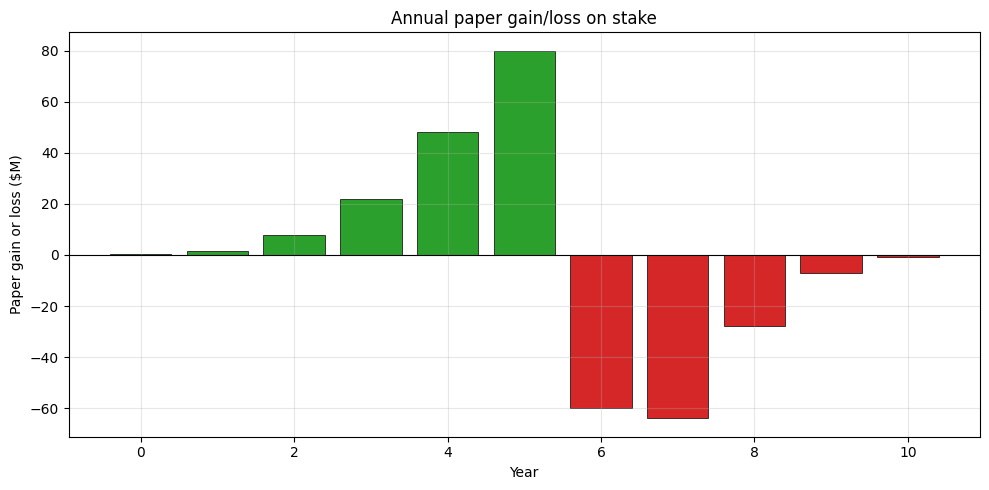

In [6]:
fig, ax = plt.subplots()
colors = ['#2ca02c' if g >= 0 else '#d62728' for g in df['annual_gain']]
ax.bar(df['year'], df['annual_gain']/1e6, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Annual paper gain/loss on stake')
ax.set_xlabel('Year')
ax.set_ylabel('Paper gain or loss ($M)')
plt.tight_layout()
plt.show()

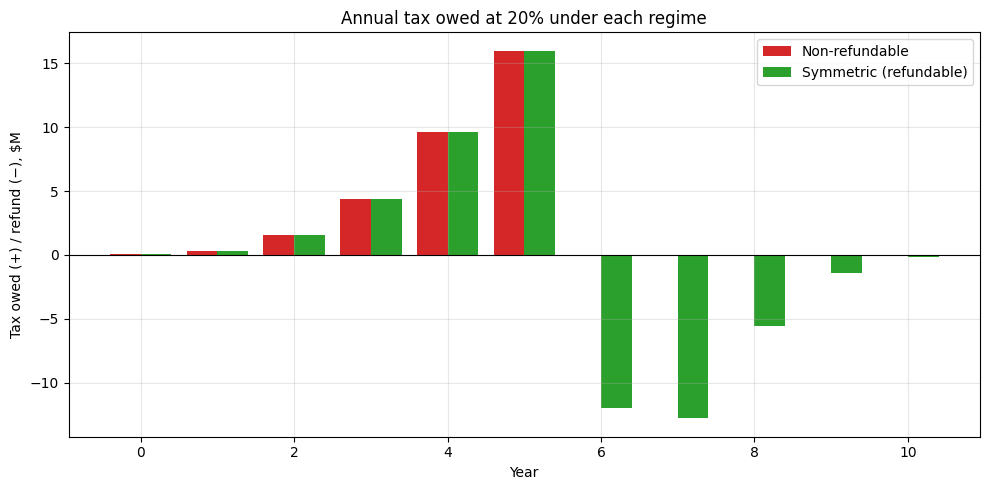

In [7]:
fig, ax = plt.subplots()
width = 0.4
ax.bar(df['year'] - width/2, df['tax_nonref']/1e6,    width, label='Non-refundable', color='#d62728')
ax.bar(df['year'] + width/2, df['tax_symmetric']/1e6, width, label='Symmetric (refundable)', color='#2ca02c')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Annual tax owed at 20% under each regime')
ax.set_xlabel('Year')
ax.set_ylabel('Tax owed (+) / refund (−), $M')
ax.legend()
plt.tight_layout()
plt.show()

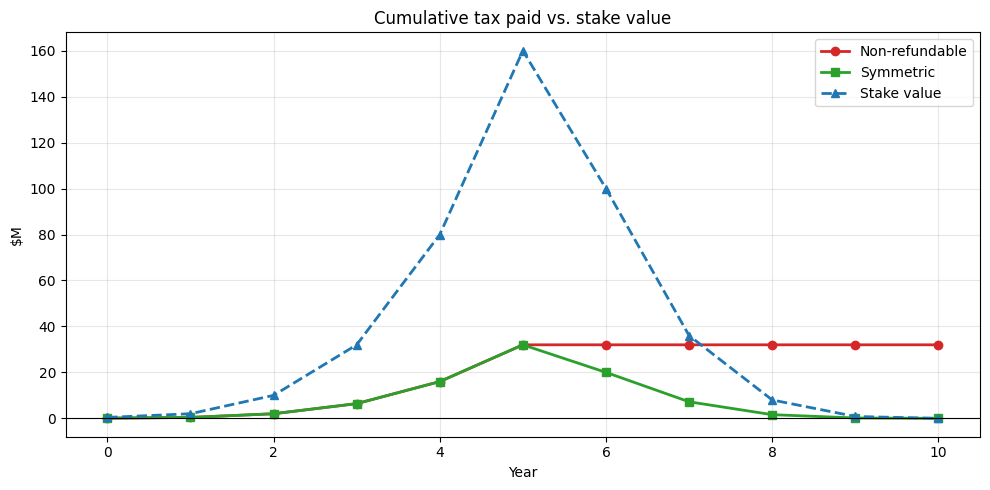

In [8]:
fig, ax = plt.subplots()
ax.plot(df['year'], df['cum_tax_nonref']/1e6,    marker='o', linewidth=2, label='Non-refundable', color='#d62728')
ax.plot(df['year'], df['cum_tax_symmetric']/1e6, marker='s', linewidth=2, label='Symmetric',      color='#2ca02c')
ax.plot(df['year'], df['stake_value']/1e6,       marker='^', linewidth=2, label='Stake value',    color='#1f77b4', linestyle='--')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Cumulative tax paid vs. stake value')
ax.set_xlabel('Year')
ax.set_ylabel('$M')
ax.legend()
plt.tight_layout()
plt.show()

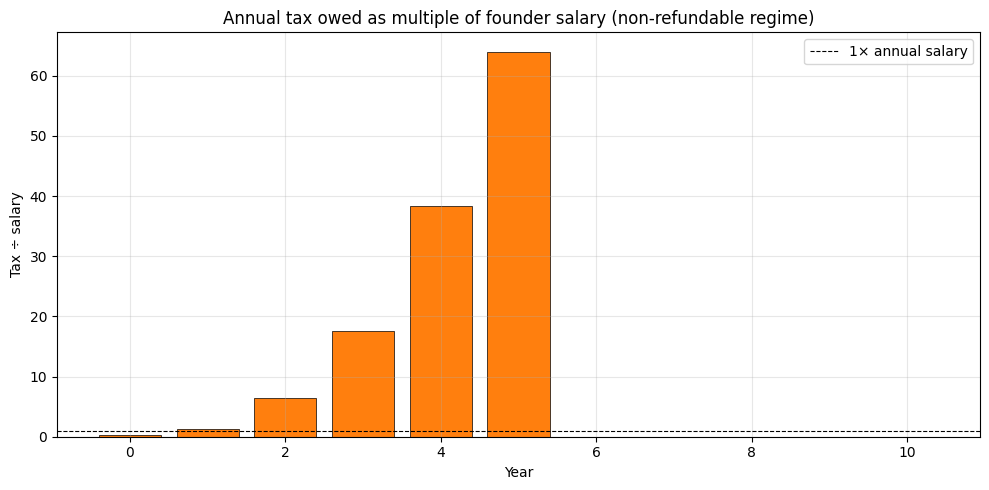

In [9]:
fig, ax = plt.subplots()
ratio = df['tax_nonref'] / df['salary']
ax.bar(df['year'], ratio, color='#ff7f0e', edgecolor='black', linewidth=0.5)
ax.axhline(1, color='black', linewidth=0.8, linestyle='--', label='1× annual salary')
ax.set_title('Annual tax owed as multiple of founder salary (non-refundable regime)')
ax.set_xlabel('Year')
ax.set_ylabel('Tax ÷ salary')
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- In the **non-refundable regime**, the founder pays substantial cash tax during the up years on stock she cannot sell (the company is private and there is no liquid market for her shares). When the company fails, she is left with a worthless stake *and* a worthless pile of loss carryforwards. Her net cash outcome is **strongly negative** even though her realized economic gain is roughly zero.
- In the **symmetric regime**, the math works out: cumulative tax over the cycle equals 20% of (final value − cost basis), which is zero. But this requires the IRS to send her refund checks during the bust years, which no real tax system does at scale.
- The peak-year tax bill is many multiples of her actual salary. To pay it she would have to either: borrow against illiquid private stock (often impossible), sell stock to other investors at the current mark (which depresses the mark and triggers the same problem for everyone else), or have the company itself fund the tax via a special distribution (which starves it of growth capital).